In [1]:
import os
import copy
import pickle
import warnings
import math
import pandas as pd
import numpy as np
import numpy.ma as ma
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import bootstrap
from matplotlib.patches import Ellipse,Annulus,Arc,PathPatch

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import palettable
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus

from astropy.utils.console import ProgressBar
from astropy.table import QTable
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

In [2]:
data_dir='/Users/xushuo/work/Project/Simulation/'
fig_dir="/Users/xushuo/work/Papers/Histrich/Figure/"

In [3]:
with open(data_dir+"galaxies_tng300_072_ell_aperture_0_4.txt",'rb') as f: 
    tab=pickle.load(f)

In [4]:
def topNselect(data,name,number):
    data_meta=data.group_by(name)
    data0=data_meta[-number::]
    return data0

In [5]:
def topNoutselect(data,name1,name2,number):
    data_meta=data.group_by(np.log10(data[name1]-data[name2]))
    data0=data_meta[-number::]
    return data0

In [8]:
mask=(tab['catsh_primary']==True)&(tab['proj']=='xy')
tab1=tab[mask]
mask1=(tab1['mass_stellar_ins']>1e10)&(tab1['mass_stellar_exs']>10**10.5)&(tab1['c_200c']<20)&(tab1['acc_rate']<20)
tab2=tab1

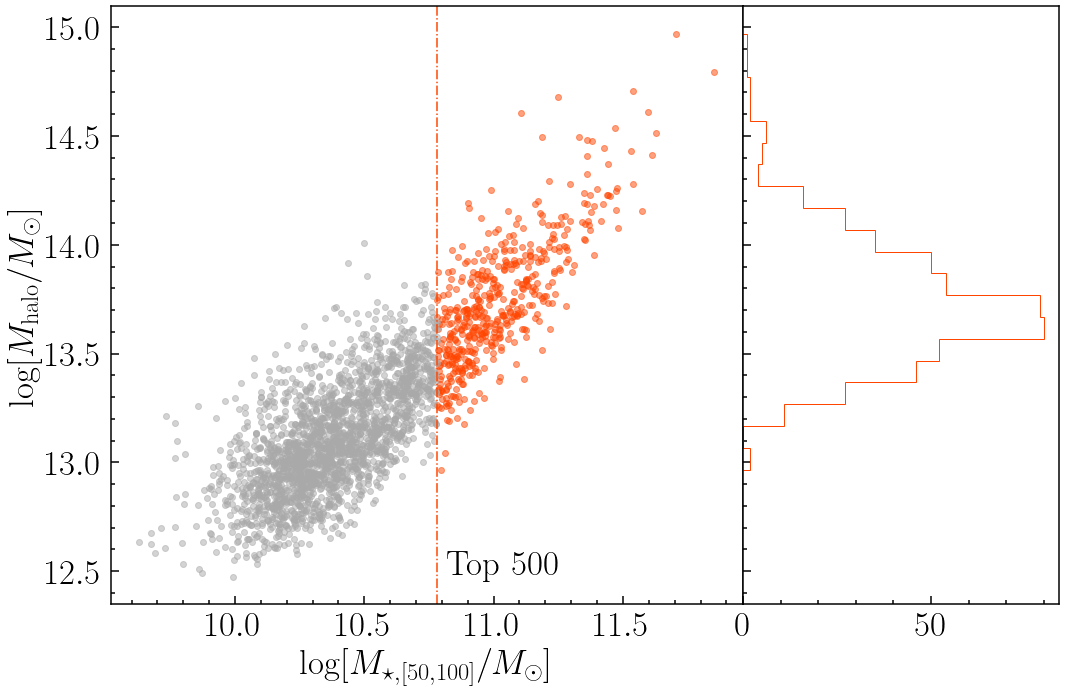

In [29]:
fig=plt.figure(figsize=(17,11))
gs = fig.add_gridspec(1,2, hspace=0,wspace=0,width_ratios=(1,0.5))
(ax1,ax2) = gs.subplots(sharey='row')
top_numb=500
ydata=np.log10(tab2[mask1]['aper_100_gal']-tab1[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata=np.log10(tab2[mask1]['mass_halo'])
ax1.scatter(ydata[mask_l],xdata[mask_l],alpha=0.5,color='orangered')
ax1.scatter(ydata[~mask_l],xdata[~mask_l],alpha=0.5,color='darkgrey')
ax1.axvline(np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])),ls='-.',lw=1.5,c='orangered')
ax1.text(0.53,0.05,r'\rm Top 500', transform=ax1.transAxes)
ax2.hist(xdata[mask_l],color='orangered',histtype='step',bins=20,orientation='horizontal')

ax1.set_xlabel(r'$\log[M_{\star,[50,100]}/M_\odot]$')
ax1.set_ylabel(r'$\log[M_{\rm halo}/M_\odot]$')
    
plt.savefig(fig_dir+"Pre4.png",dpi=100)
    

    
 

